In [1]:
import os
import re
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS

### Plot Styles

In [2]:
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (10, 4)})

### Load data path

In [3]:
EXTRACTED_DIR = Path("../Extracted_data")   # output of extract_resumes.py
LOG_CSV       = Path("../extraction_log.csv")

print(f"Extracted dir exists: {EXTRACTED_DIR.exists()}")

Extracted dir exists: True


### Load Extracted Resumes

In [4]:
records = []

for occ_dir in sorted(EXTRACTED_DIR.iterdir()):
    if not occ_dir.is_dir():
        continue
    for txt_file in sorted(occ_dir.glob("*.txt")):
        text = txt_file.read_text(encoding="utf-8")
        # Strip page markers added by extractor
        clean = re.sub(r"--- Page \d+ (?:\(OCR\) )?---", "", text).strip()
        records.append({
            "occupation": occ_dir.name,
            "filename":   txt_file.name,
            "filepath":   str(txt_file),
            "text":       clean,
            "char_count": len(clean),
            "word_count": len(clean.split()),
            "page_count": text.count("--- Page"),
        })

df = pd.DataFrame(records)
print(f"Total resumes loaded : {len(df)}")
print(f"Occupations          : {df['occupation'].nunique()}")
print(f"\nSample:\n{df[['occupation','filename','word_count','page_count']].head(10)}")


Total resumes loaded : 2484
Occupations          : 24

Sample:
   occupation      filename  word_count  page_count
0  ACCOUNTANT  10554236.txt        3469           5
1  ACCOUNTANT  10674770.txt        1047           2
2  ACCOUNTANT  11163645.txt         628           2
3  ACCOUNTANT  11759079.txt         849           2
4  ACCOUNTANT  12065211.txt         783           2
5  ACCOUNTANT  12202337.txt         743           2
6  ACCOUNTANT  12338274.txt         810           2
7  ACCOUNTANT  12442909.txt         656           2
8  ACCOUNTANT  12780508.txt         994           2
9  ACCOUNTANT  12802330.txt         817           2


In [5]:
# Merge with extraction log for method/status metadata
if LOG_CSV.exists():
    log_df = pd.read_csv(LOG_CSV)
    log_df["_stem"] = log_df["filename"].str.replace(r"\.pdf$", "", regex=True)
    df["_stem"]     = df["filename"].str.replace(r"\.txt$", "", regex=True)
    df = df.merge(
        log_df[["_stem", "method", "status", "error"]],
        on="_stem", how="left"
    ).drop(columns="_stem")
    print("Merged extraction log")
    print(df[["filename", "method", "status"]].head())
else:
    print("extraction_log.csv not found — skipping merge")


Merged extraction log
       filename             method status
0  10554236.txt  native_pdfplumber     ok
1  10674770.txt  native_pdfplumber     ok
2  11163645.txt  native_pdfplumber     ok
3  11759079.txt  native_pdfplumber     ok
4  12065211.txt  native_pdfplumber     ok


### Dataset Overview

In [8]:
print("=== Shape ===")
print(df.shape)

print("\n=== dtypes ===")
print(df.dtypes)

print("\n=== Missing values ===")
print(df.isnull().sum())

print("\n=== Extraction methods ===")
if "method" in df.columns:
    print(df["method"].value_counts())


=== Shape ===
(2484, 10)

=== dtypes ===
occupation      str
filename        str
filepath        str
text            str
char_count    int64
word_count    int64
page_count    int64
method          str
status          str
error           str
dtype: object

=== Missing values ===
occupation       0
filename         0
filepath         0
text             0
char_count       0
word_count       0
page_count       0
method           1
status           0
error         2483
dtype: int64

=== Extraction methods ===
method
native_pdfplumber    2483
Name: count, dtype: int64


In [10]:
df[df['method'].isna()]

,occupation,filename,filepath,text,char_count,word_count,page_count,method,status,error
802,BUSINESS-DEVELOPMENT,12632728.txt,..\Extracted_data\BUSINESS-DEVELOPMENT\1263272...,,0,0,0,NaN,error,name 'extract_scanned' is not defined


In [11]:
TARGET = "12632728"

# Drop from disk
target_files = list(EXTRACTED_DIR.glob(f"**/{TARGET}.txt"))
for f in target_files:
    f.unlink()
    print(f"Deleted from disk: {f}")

# Drop from df
before = len(df)
df = df[df["filename"] != f"{TARGET}.txt"].reset_index(drop=True)
print(f"Dropped from df: {before - len(df)} row(s) — df now {len(df)} rows")

# Drop from log_df and overwrite CSV
if LOG_CSV.exists():
    log_df = pd.read_csv(LOG_CSV)
    before_log = len(log_df)
    log_df = log_df[log_df["filename"] != f"{TARGET}.pdf"].reset_index(drop=True)
    log_df.to_csv(LOG_CSV, index=False)
    print(f"Dropped from log_df: {before_log - len(log_df)} row(s) — log now {len(log_df)} rows")

Deleted from disk: ..\Extracted_data\BUSINESS-DEVELOPMENT\12632728.txt
Dropped from df: 1 row(s) — df now 2483 rows
Dropped from log_df: 1 row(s) — log now 2483 rows


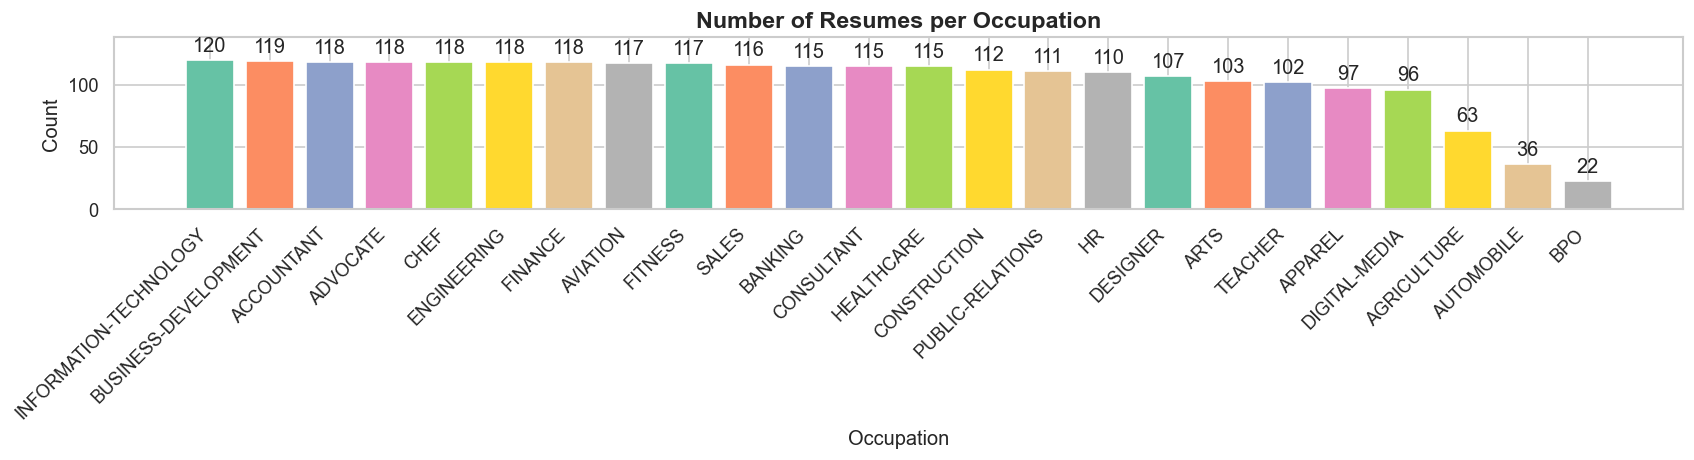

            occupation  count
INFORMATION-TECHNOLOGY    120
  BUSINESS-DEVELOPMENT    119
            ACCOUNTANT    118
              ADVOCATE    118
                  CHEF    118
           ENGINEERING    118
               FINANCE    118
              AVIATION    117
               FITNESS    117
                 SALES    116
               BANKING    115
            CONSULTANT    115
            HEALTHCARE    115
          CONSTRUCTION    112
      PUBLIC-RELATIONS    111
                    HR    110
              DESIGNER    107
                  ARTS    103
               TEACHER    102
               APPAREL     97
         DIGITAL-MEDIA     96
           AGRICULTURE     63
            AUTOMOBILE     36
                   BPO     22


In [13]:
occ_counts = df["occupation"].value_counts().reset_index()
occ_counts.columns = ["occupation", "count"]

fig, ax = plt.subplots(figsize=(max(8, len(occ_counts) * 0.6), 4))
bars = ax.bar(occ_counts["occupation"], occ_counts["count"],
              color=sns.color_palette("Set2", len(occ_counts)))
ax.bar_label(bars, padding=3)
ax.margins(y=0.15)
ax.set_title("Number of Resumes per Occupation", fontsize=14, fontweight="bold")
ax.set_xlabel("Occupation")
ax.set_ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print(occ_counts.to_string(index=False))


### Text Length Analysis

In [14]:
print("=== Word count stats (overall) ===")
print(df["word_count"].describe().round(1))

=== Word count stats (overall) ===
count    2483.0
mean      812.7
std       361.9
min       113.0
25%       652.5
50%       760.0
75%       934.5
max      5190.0
Name: word_count, dtype: float64


In [23]:
df.loc[df["word_count"].idxmax(), ["filename", "occupation", "word_count", "page_count"]]

filename          11842274.txt
occupation    PUBLIC-RELATIONS
word_count                5190
page_count                   9
Name: 2161, dtype: object

Assume files that have more than 5 pages, haves duplicated content

In [21]:
df[df["page_count"] > 5][["filename", "occupation", "word_count", "page_count"]]

,filename,occupation,word_count,page_count
527,51508889.txt,AUTOMOBILE,2901,6
1119,39908485.txt,CONSTRUCTION,4000,7
1405,23085604.txt,DIGITAL-MEDIA,3302,6
2161,11842274.txt,PUBLIC-RELATIONS,5190,9


Only file 11842274 that has duplicated content -> introduces noise to BERT -> drop file

In [24]:
TARGET = "11842274"

# Drop from disk
target_files = list(EXTRACTED_DIR.glob(f"**/{TARGET}.txt"))
for f in target_files:
    f.unlink()
    print(f"Deleted from disk: {f}")

# Drop from df
before = len(df)
df = df[df["filename"] != f"{TARGET}.txt"].reset_index(drop=True)
print(f"Dropped from df: {before - len(df)} row(s) — df now {len(df)} rows")

# Drop from log_df and overwrite CSV
if LOG_CSV.exists():
    log_df = pd.read_csv(LOG_CSV)
    before_log = len(log_df)
    log_df = log_df[log_df["filename"] != f"{TARGET}.pdf"].reset_index(drop=True)
    log_df.to_csv(LOG_CSV, index=False)
    print(f"Dropped from log_df: {before_log - len(log_df)} row(s) — log now {len(log_df)} rows")

Deleted from disk: ..\Extracted_data\PUBLIC-RELATIONS\11842274.txt
Dropped from df: 1 row(s) — df now 2482 rows
Dropped from log_df: 1 row(s) — log now 2482 rows


In [27]:
print("=== Word count stats (overall) ===")
print(df["word_count"].describe().round(1))

=== Word count stats (overall) ===
count    2482.0
mean      811.0
std       351.1
min       113.0
25%       652.2
50%       760.0
75%       934.0
max      4000.0
Name: word_count, dtype: float64


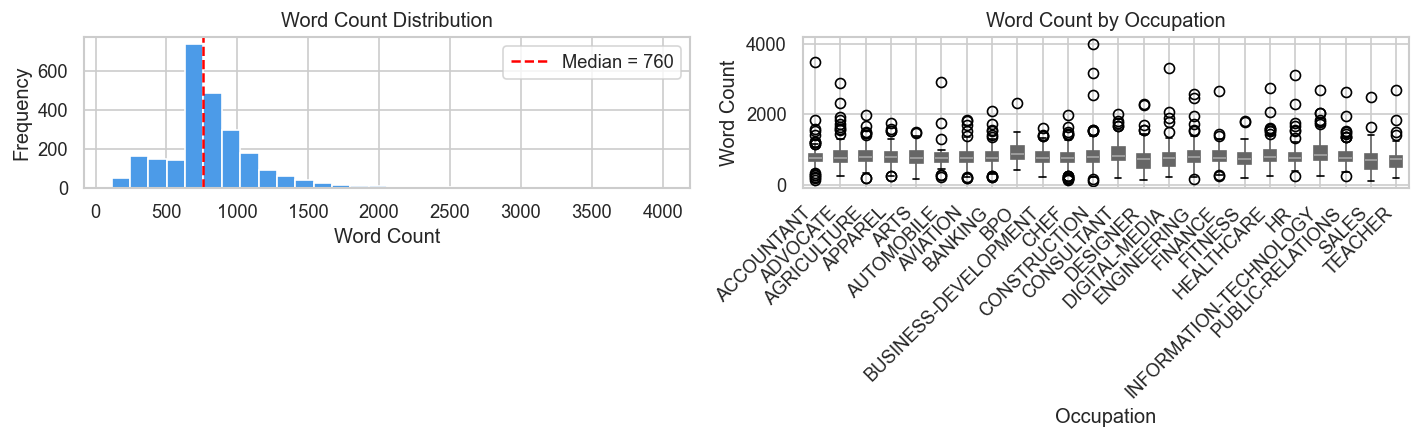

In [28]:
# Distribution of word counts
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(df["word_count"], bins=30, color="#4C9BE8", edgecolor="white")
axes[0].axvline(df["word_count"].median(), color="red", linestyle="--",
                label=f"Median = {df['word_count'].median():.0f}")
axes[0].set_title("Word Count Distribution")
axes[0].set_xlabel("Word Count")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# Box plot by occupation
if df["occupation"].nunique() > 1:
    df.boxplot(column="word_count", by="occupation", ax=axes[1],
               patch_artist=True)
    axes[1].set_title("Word Count by Occupation")
    axes[1].set_xlabel("Occupation")
    axes[1].set_ylabel("Word Count")
    plt.sca(axes[1])
    plt.xticks(rotation=45, ha="right")
else:
    axes[1].axis("off")
    axes[1].text(0.5, 0.5, "Add more occupations\nfor comparison",
                 ha="center", va="center", transform=axes[1].transAxes,
                 fontsize=12, color="gray")

plt.suptitle("")
plt.tight_layout()
plt.show()


In [29]:
# Per-occupation word count summary
print("=== Word count by occupation ===")
print(
    df.groupby("occupation")["word_count"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(1)
    .rename(columns={"count":"n_resumes", "mean":"avg_words",
                     "median":"med_words", "min":"min_words", "max":"max_words"})
)


=== Word count by occupation ===
                        n_resumes  avg_words  med_words  min_words  max_words
occupation                                                                   
ACCOUNTANT                    118      802.0      750.0        143       3469
ADVOCATE                      118      852.1      758.5        266       2890
AGRICULTURE                    63      859.4      795.0        192       1970
APPAREL                        97      779.4      784.0        250       1752
ARTS                          103      778.8      761.0        172       1509
AUTOMOBILE                     36      810.8      753.0        213       2901
AVIATION                      117      796.7      761.0        195       1829
BANKING                       115      804.9      750.0        224       2101
BPO                            22      976.1      880.5        430       2310
BUSINESS-DEVELOPMENT          119      783.7      751.0        216       1607
CHEF                          1